In [1]:
import cv2
import numpy as np
import torch 

import tensorflow as tf
import pandas as pd

import pathlib 
import os
import string
from PIL import Image
from keras import backend as K
import matplotlib.pyplot as plt
import torch.nn as nn
import torch.nn.functional as F
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import torchvision
from torchvision import transforms
from torchvision.datasets import ImageFolder
from torchvision.utils import make_grid

from torch.utils.data.dataloader import DataLoader
from torch.utils.data import random_split

import matplotlib.pyplot as plt
from PIL import Image
import random, os
import numpy as np
import shap

In [2]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

#train and test data directory
train_dir = "Dataset/train"
test_dir = "Dataset/test"
val_dir = "Dataset/valid"
num_train_files = sum([len(files) for r, d, files in os.walk(train_dir)])
num_test_files = sum([len(files) for r, d, files in os.walk(test_dir)])
num_val_files = sum([len(files) for r, d, files in os.walk(val_dir)])

print(f"Number of files in the train directory: {num_train_files}")
print(f"Number of files in the test directory: {num_test_files}")
print(f"Number of files in the test directory: {num_val_files}")

Number of files in the train directory: 10000
Number of files in the test directory: 1703
Number of files in the test directory: 9199


In [3]:
class ImageFolderEX(torchvision.datasets.ImageFolder):
    def __getitem__(self, index):
        path, target = self.samples[index]
        try:
            sample = self.loader(path)
        except:
            return None
        if self.transform is not None:
            sample = self.transform(sample)
        if self.target_transform is not None:
            target = self.target_transform(target)
        return sample, target
transform = transforms.Compose([transforms.Resize((128,128)),
                                transforms.ToTensor()])

In [4]:
#load the train and test data
dataset = ImageFolderEX(train_dir, transform = transform)
test_ds = ImageFolderEX(test_dir, transform = transform)

print('dataset samples:', len(dataset))
print('test samples:', len(test_ds))
print("Classes are:", dataset.classes)

img, label = dataset[0]
print(f'Example: first sample size: {img.shape}, and label: {label}')

dataset samples: 10000
test samples: 1703
Classes are: ['colon_aca', 'colon_n']
Example: first sample size: torch.Size([3, 128, 128]), and label: 0


In [5]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
ge = ImageDataGenerator(rescale = 1/255,
                        rotation_range=0.2,
                        width_shift_range=0.05,
                        height_shift_range=0.05,
                        fill_mode = 'constant',
                        validation_split = 0.2,
                        horizontal_flip = True,
                        vertical_flip = True,
                        zoom_range = 0.2
                       )

In [6]:
datasetfolder = 'Dataset/train'
dataflowtraining = ge.flow_from_directory(directory = datasetfolder,
                                 target_size = (128, 128),
                                 color_mode = 'rgb',
                                 batch_size = 64,
                                 shuffle = True,
                                 subset = 'training')
datasetfolder1='Dataset/train'
dataflowvalidation = ge.flow_from_directory(directory = datasetfolder1,
                                           target_size = (128, 128),
                                           color_mode = 'rgb',
                                           batch_size = 64,
                                           shuffle = True,
                                           subset = 'validation')

Found 8000 images belonging to 2 classes.
Found 2000 images belonging to 2 classes.


In [7]:
batch = next(dataflowvalidation)
images, labels = batch
print(np.min(images), np.max(images))

0.0 1.0


C:\Users\nishu\AppData\Local\Temp\ipykernel_18584\1089697816.py:6: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


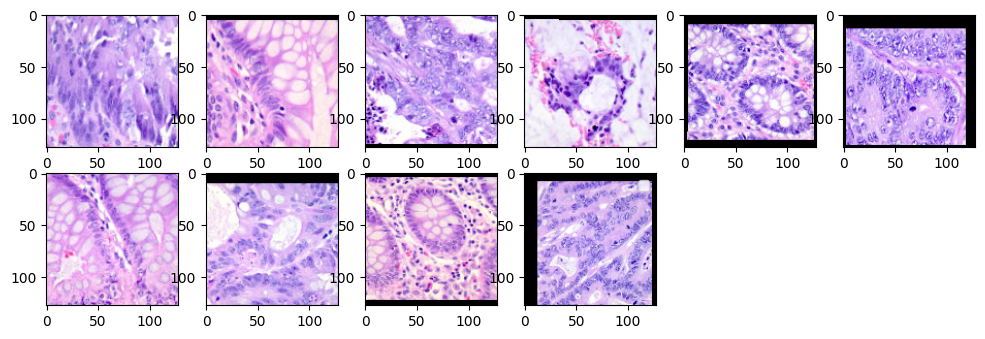

In [8]:
plt.figure(figsize = (12, 12))
for i in range(10):
    plt.subplot(6, 6, (i + 1))
    plt.imshow(images[i])

plt.legend()

In [9]:
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras import layers, Model
import tensorflow as tf

basemodel = DenseNet121(weights='imagenet', include_top=False, input_shape=(128, 128, 3), pooling=None)

x = tf.keras.layers.Flatten()(basemodel.output)
x = tf.keras.layers.Dropout(0.2)(x)
x = tf.keras.layers.BatchNormalization()(x)
x = tf.keras.layers.Dropout(0.3)(x)
x = tf.keras.layers.Dense(16, activation='relu')(x)
x = tf.keras.layers.Dropout(0.4)(x)
x = tf.keras.layers.BatchNormalization()(x)
output = tf.keras.layers.Dense(2, activation='softmax')(x)

# Define the final model
m = Model(inputs=basemodel.input, outputs=output)

# Compile the model
m.compile(
    loss='binary_crossentropy',
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    metrics=['accuracy', tf.keras.metrics.Precision(name='precision'), tf.keras.metrics.Recall(name='recall')]
)

In [10]:
print(m.summary())

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)      │ (None, 128, 128, 3)       │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ zero_padding2d                │ (None, 134, 134, 3)       │               0 │ input_layer[0][0]          │
│ (ZeroPadding2D)               │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv1_conv (Conv2D)           │ (None, 64, 64, 64)        │           9,408 │ zero_padding2d[0][0]       │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv1_bn (BatchNormalization) │ (None, 64, 64, 64)        │             256 │ conv1_conv[0][0]           │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv1_relu (Activation)       │ (None, 64, 64, 64)        │               0 │ conv1_bn[0][0]             │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ zero_padding2d_1              │ (None, 66, 66, 64)        │               0 │ conv1_relu[0][0]           │
│ (ZeroPadding2D)               │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ pool1 (MaxPooling2D)          │ (None, 32, 32, 64)        │               0 │ zero_padding2d_1[0][0]     │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2_block1_0_bn             │ (None, 32, 32, 64)        │             256 │ pool1[0][0]                │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2_block1_0_relu           │ (None, 32, 32, 64)        │               0 │ conv2_block1_0_bn[0][0]    │
│ (Activation)                  │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2_block1_1_conv (Conv2D)  │ (None, 32, 32, 128)       │           8,192 │ conv2_block1_0_relu[0][0]  │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2_block1_1_bn             │ (None, 32, 32, 128)       │             512 │ conv2_block1_1_conv[0][0]  │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2_block1_1_relu           │ (None, 32, 32, 128)       │               0 │ conv2_block1_1_bn[0][0]    │
│ (Activation)                  │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2_block1_2_conv (Conv2D)  │ (None, 32, 32, 32)        │          36,864 │ conv2_block1_1_relu[0][0]  │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2_block1_concat           │ (None, 32, 32, 96)        │               0 │ pool1[0][0],               │
│ (Concatenate)                 │                           │               

 Total params: 7,365,298 (28.10 MB)

 Trainable params: 7,248,850 (27.65 MB)

 Non-trainable params: 116,448 (454.88 KB)

None


In [ ]:
hist = m.fit(dataflowtraining, epochs = 20, batch_size = 64,
             validation_data = dataflowvalidation,
             callbacks = [
                tf.keras.callbacks.EarlyStopping(patience = 4, monitor = 'val_loss', mode = 'min',
                                                restore_best_weights = True),
                tf.keras.callbacks.ReduceLROnPlateau(patience = 4, monitor = 'val_loss',
                                                          mode = 'min', factor = 0.1)
            ])

Epoch 1/20


C:\Users\nishu\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


125/125 ━━━━━━━━━━━━━━━━━━━━ 909s 7s/step - accuracy: 0.8769 - loss: 0.4167 - precision: 0.8769 - recall: 0.8769 - val_accuracy: 0.9990 - val_loss: 0.1414 - val_precision: 0.9990 - val_recall: 0.9990 - learning_rate: 1.0000e-04
Epoch 2/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 879s 7s/step - accuracy: 0.9889 - loss: 0.2113 - precision: 0.9889 - recall: 0.9889 - val_accuracy: 0.9995 - val_loss: 0.1525 - val_precision: 0.9995 - val_recall: 0.9995 - learning_rate: 1.0000e-04
Epoch 3/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 7s/step - accuracy: 0.9970 - loss: 0.1755 - precision: 0.9970 - recall: 0.9970